In [7]:
%matplotlib widget

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import Tuple

In [9]:
image = Image.open("fermat.png").convert("RGBA")
image_array = np.array(image)

obj_width = np.sqrt(2)  # side length for square to fit in unit circle
obj_height = np.sqrt(2) 

# Pixel dimensions
h, w = image_array.shape[:2]

Rf = 3
arc_angle = 170 # deg
base = (0, 0)

# starting pos
step = 0.1  # m
x_obj = 0
y_obj = base[0] + obj_height / 2
obj_radius = 0.5

In [10]:
def map_coords_to_circle_arc(xy: Tuple[np.ndarray, np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    x, y = xy
    
    # map y to radial distances on the arc
    r_dash = (1 - y) / 2 * (Rf - 1) + 1
    
    # maps x to angles on the arc
    arc_angle_rad = np.deg2rad(arc_angle)
    theta_dash = x * (arc_angle_rad / 2)
    
    # convert polar coords back into polar
    X = r_dash * np.sin(theta_dash)
    Y = -r_dash * np.cos(theta_dash) # arc points downard from the base

    return (X, Y)

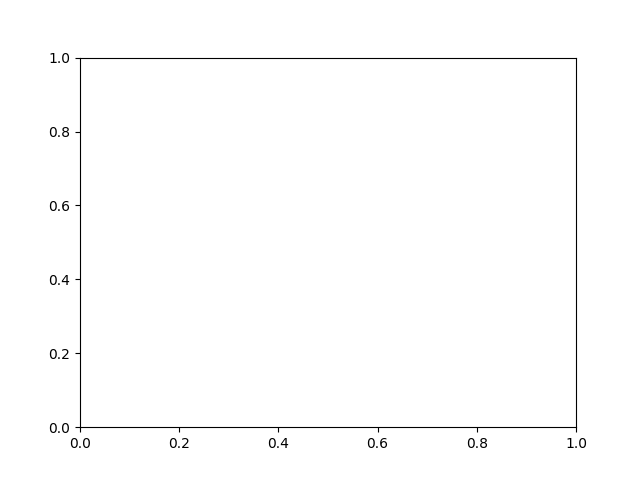

In [11]:
fig, ax = plt.subplots()

def plot_scene():
    ax.clear()

    # Plot the original object image (as if projected onto the scene)
    ax.imshow(
        image_array,
        extent=(
            x_obj - obj_width / 2,
            x_obj + obj_width / 2,
            y_obj - obj_height / 2,
            y_obj + obj_height / 2,
        ),
    )

    # Distorted image plotting
    x_lin = np.linspace(x_obj - obj_width / 2, x_obj + obj_width / 2, w)
    y_lin = np.linspace(y_obj - obj_height / 2, y_obj + obj_height / 2, h)
    xx, yy = np.meshgrid(x_lin, y_lin)

    mask = (xx != 0)

    # Apply the mirror transformation to all coordinates
    X, Y = map_coords_to_circle_arc((xx[mask], yy[mask]))

    if X.size == 0 or Y.size == 0:
        print("Warning: X or Y are empty after mapping, nothing to scatter.")

    pixels = image_array[mask] / 255.0  # Normalize pixel values for scatter color
    ax.scatter(X, Y, c=pixels, s=1)  # Plot the distorted image as individual pixels

    # Add unit circle
    circle_center = (0, obj_height / 2)
    
    circle = plt.Circle(circle_center, radius=1, fill=False, color='blue', linestyle='--', label='Unit Circle')
    ax.add_patch(circle)

    ax.plot(0, 0, marker='o', color='red', label='Object Base')

    ax.set_title(
        f"Object Mapped to Circle Arc"
    )
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 2)
    ax.set_xlabel("X / m")
    ax.set_ylabel("Y / m")
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

    fig.canvas.draw()


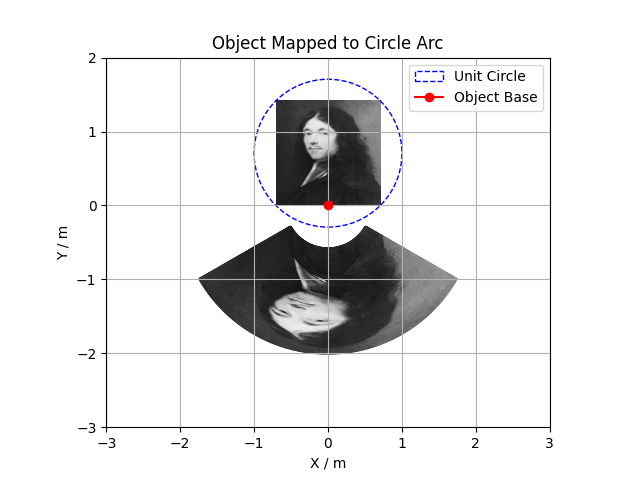

In [12]:
plot_scene()
plt.show()